In [4]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import numpy as np
from matplotlib.ticker import FuncFormatter
def format_k(value, tick_number):
    return f"{value / 1000:.1f}k"
formatter = FuncFormatter(format_k)

from matplotlib.ticker import FixedLocator
from Utils import *
data_path = "quantum_network_compiler-minimal_codes/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cache_size'
data_path_list = [data_path+'/split_mul']
benchmark = ['xor','qft','grover','rca', 'qaoa']
eval = ['split_mul']
line_width = 3
marker_size = 8

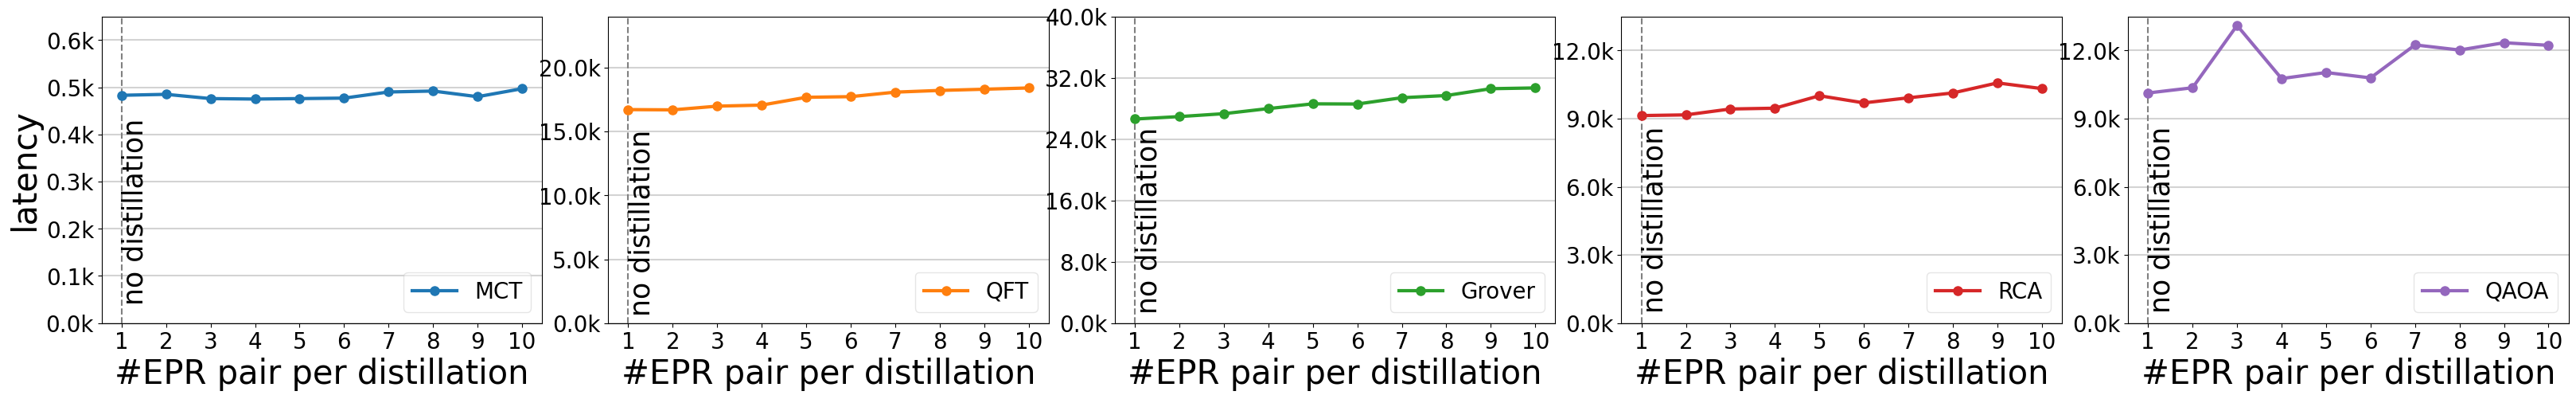

In [5]:
tick_font = 20
labelpad = 10
fig, axs = plt.subplots(1, 5, figsize=(40, 5), gridspec_kw={'wspace': 0.15})
normalize = False

label_mapping = {
    "Benchmark-0": "MCT",
    "Benchmark-0-baseline": "MCT-baseline",
    "Benchmark-1": "QFT",
    "Benchmark-1-baseline": "QFT-baseline",
    "Benchmark-2": "Grover",
    "Benchmark-2-baseline": "Grover-baseline",
    "Benchmark-3": "RCA",
    "Benchmark-3-baseline": "RCA-baseline",
    "Benchmark-4": "QAOA",
    "Benchmark-4-baseline": "QAOA-baseline"

}
plt.subplots_adjust(wspace=0.1, hspace=0.2)
diction_our, diction_baseline = compute_dictionaries(data_path_list[0], eval[0], benchmark)
diction_our_const = diction_our
d = 0.005
x_coor = range(1,11)
xlabel = '#EPR pair per distillation'

#FIG 10 c1
i = 0
diction_our[0][i] = diction_our_const[0][i][:10]
ylabel1 = 'latency'
ss = axs[0].get_subplotspec()
axs[i].set_yticklabels([])                  
axs[i].set_xticklabels([])                   
axs[0].set_ylabel(ylabel1, fontsize=30, color='black')
axs[0].vlines(x_coor[0],ymin = 0, ymax = 1000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[0].text(1,50,'no distillation',rotation = 90, fontsize = 25)
axs[0].xaxis.set_major_locator(FixedLocator(x_coor))
axs[0].yaxis.set_major_formatter(formatter)
axs[0].set_xticklabels([1,2,3,4,5,6,7,8,9,10])


#FIG 10 c2
i = 1
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[1].vlines(x_coor[0],ymin = 0, ymax = 25000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[1].text(1,1000,'no distillation',rotation = 90, fontsize = 25)
axs[1].set_xticks(x_coor)


#FIG 10 c3
i = 2
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[2].vlines(x_coor[0],ymin = 0, ymax = 200000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[2].text(1,2000,'no distillation',rotation = 90, fontsize = 25)
axs[2].set_xticks(x_coor)


# FIG 10 c4
i = 3
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[3].vlines(x_coor[0],ymin = 0, ymax = 70000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[3].text(1,700,'no distillation',rotation = 90, fontsize = 25)
axs[3].set_xticks(x_coor)

# FIG 10 c5
i = 4
diction_our[0][i] = diction_our_const[0][i][:10]
max_y = max(max([a/diction_baseline[0][i][0] for a in diction_our[0][i]]), diction_baseline[0][i][0]) if normalize else max(max(diction_our[0][i]), diction_baseline[0][i][0])
axs[4].vlines(x_coor[0],ymin = 0, ymax = 70000,  colors='gray', linestyles='dashed', linewidth=1.5)
axs[4].text(1,700,'no distillation',rotation = 90, fontsize = 25)
axs[4].set_xticks(x_coor)


for i in range(5):
    label_key = f"Benchmark-{i}"
    baseline_key = f"Benchmark-{i}-baseline"
    axs[i].plot(x_coor, diction_our[0][i], label=label_mapping[label_key], color=f'C{i}', marker='o', linestyle='-', linewidth=line_width, markersize=marker_size)
    axs[i].set_xlabel(xlabel, fontsize=30, color='black')
    axs[i].legend(fontsize=20, loc='lower right', framealpha=0.5)
    axs[i].tick_params(axis = 'x', labelsize = tick_font)
    axs[i].tick_params(axis = 'y', labelsize = tick_font)
    axs[i].grid(True, which='both', axis='y', linestyle='-', linewidth=1.5, color='lightgray') 


axs[0].yaxis.set_major_formatter(formatter)
axs[0].yaxis.set_major_locator(FixedLocator([0,100,200,300,400,500,600]))
axs[1].yaxis.set_major_locator(FixedLocator([0,5000,10000,15000,20000,25000]))
axs[2].yaxis.set_major_locator(FixedLocator([0,8000,16000,24000,32000,40000]))
axs[3].yaxis.set_major_locator(FixedLocator([0,3000,6000,9000,12000,15000]))
axs[4].yaxis.set_major_locator(FixedLocator([0,3000,6000,9000,12000,15000]))


for i in [1,2,3]:
    axs[i].set_xticklabels([1,2,3,4,5,6,7,8,9,10])
axs[0].set_ylim(0,650)
axs[1].set_ylim(0,24000)
axs[2].set_ylim(0,40000)
axs[3].set_ylim(0,13500)
axs[4].set_ylim(0,13500)


axs[0].yaxis.set_major_formatter(formatter)
axs[1].yaxis.set_major_formatter(formatter)
axs[2].yaxis.set_major_formatter(formatter)
axs[3].yaxis.set_major_formatter(formatter)
axs[4].yaxis.set_major_formatter(formatter)


plt.savefig('fig/FIG_10c.pdf', bbox_inches='tight')

plt.show()
